In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение генератора случайных чисел
import random

In [ ]:
# Ячейка № 2

# задание функции,
# возвращающей значения
# потенциала Леннарда-Джонсона
def V(R):
    Np = len(R)
    z = np.zeros(Np)
    z = 4 * (1 / R**12 - 1 / R**6)

    return z


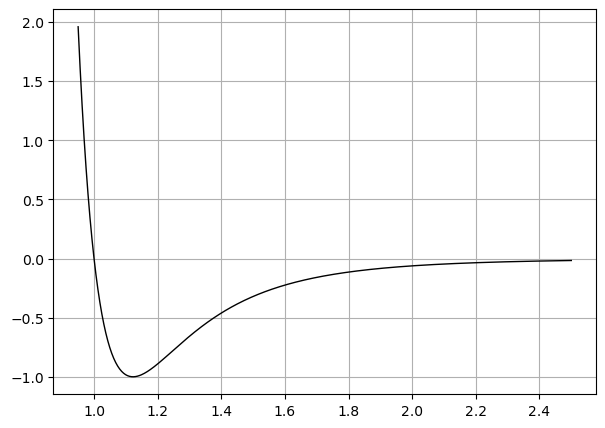

In [ ]:
# Ячейка № 3

# визуализация потенциала
# Леннарда-Джонсона

# задание границ интервала
# для вычисления значений
# потенциала Леннарда-Джонсона
R_min = 0.95
R_max = 2.5

# задание числа узлов сетки
# по переменной R
Np = 500

# вычисление координат
# узлов сетки по переменной R
R = np.linspace(R_min, R_max, Np)

# вычисление значений
# потенциала Леннарда-Джонсона
# в узлах выбранной сетки
U = V(R)

# визуализация потенциала
# Леннарда-Джонсона

fig = plt.figure(figsize=(7, 5))

plt.plot(R, U, "-k", lw=1)
plt.grid(True)

plt.show()

In [ ]:
# Ячейка № 4

# задание функции, возвращающей
# начальное состояние
# моделируемой системы
def Init(Lx, Ly, Nx, Ny, Vmax):
    #  входные переменные:
    # Lx - ширина МД ячейки
    # Ly - высота МД ячейки
    # Nx - ширина начальной ячейки
    # Ny - высота начальной ячейки
    # Vmax - максимальное значение скорости

    # вычисление числа вершин
    # используемых ячеек
    Pos_row = Ly / (Ny + 1)
    Pos_col = Lx / (Nx + 1)

    # вычисление числа частиц системы
    N = Nx * Ny

    # инициализация массивов, используемых
    # для хранения начальных значений
    # координат (x, y) и скоростей (Vx, Vy)
    # моделируемой системы
    x = np.zeros(N)
    y = np.zeros(N)
    Vx = np.zeros(N)
    Vy = np.zeros(N)

    # инициализация генератора случайных чисел
    random.seed()

    # задание начального состояния
    # моделируемой системы
    i = 0
    for Rows in range(Ny):
        for Cols in range(Nx):
            # задание начальных координат частиц
            x[i] = Pos_col * (Cols + 1) / 2
            y[i] = Pos_row * (Rows + 1)
            # задание начальных скоростей частиц
            Vx[i] = Vmax * (2 * random.uniform(0, 1) - 1)
            Vy[i] = Vmax * (2 * random.uniform(0, 1) - 1)
            i = i + 1

    # вычисление проекций скорости
    # центра масс моделируемой системы
    Vx_full = np.mean(Vx)
    Vy_full = np.mean(Vy)
    # вычисление отклонений
    # проекций скоростей
    # частиц от соответствующих
    # проекций скорости центра
    # масс моделируемой системы
    Vx = Vx - Vx_full
    Vy = Vy - Vy_full

    # размешение начальных значений
    # координат и скоростей частиц
    # моделируемой системы относительно
    # относительно ее центра масс
    # в массиве z
    z = np.vstack([x, y, Vx, Vy])

    # транспонирование матрицы z
    z = z.transpose()

    return z

In [5]:
# Ячейка № 5

# задание функции, возвращающей
# значение проекции на ось оХ
# силы, действующей на частицу
def Fx(x, y):
    z = (
        -(2 ** (7 / 3))
        * (np.pi**2)
        / 3
        * x
        * (-2 / (x**2 + y**2) ** 7 + 1 / (x**2 + y**2) ** 4)
    )
    return z

In [6]:
# Ячейка № 6

# задание функции, возвращающей
# значение проекции на ось оХ
# силы, действующей на частицу
def Fy(x, y):
    z = (
        -(2 ** (7 / 3))
        * (np.pi**2)
        / 3
        * y
        * (-2 / (x**2 + y**2) ** 7 + 1 / (x**2 + y**2) ** 4)
    )
    return z

In [7]:
# Ячейка № 7

# задание функции, возвращающей значения
# координат, составляющих скорости и
# ускорений вдоль соответствующих
# координатных осей
def Acc(R_V, Lx, Ly, N):
    # входные переменные:
    # R_V - матрица, возвращенная функцией Init
    # Lx - ширина МД ячейки
    # Ly - высота МД ячейки
    # N - число частиц моделируемой системы

    # инициализация массивов Ax, Ay,
    # используемых для хранения
    # значений проекций ускорений
    # частиц моделируемой системы
    Ax = np.zeros(N)
    Ay = np.zeros(N)

    # инициализация массива Pe,
    # используемого для хранения
    # потенциальной энергии взаимодействия
    # частиц моделируемой системы
    Pe = np.zeros(N)

    # вычисление значений проекций
    # ускорений частиц моделируемой системы
    # на оси координат и
    # потенциальной энергии взаимодействия
    # частиц моделируемой системы
    Ep = 0
    for i in range(N - 1):
        for j in range(i + 1, N):
            Dx = R_V[i, 0] - R_V[j, 0]
            Dy = R_V[i, 1] - R_V[j, 1]
            # проверка граничных
            # условий по оси ОX
            if abs(Dx) > Lx / 2:
                Dx = Dx - np.sign(Dx) * Lx
            # проверка граничных условий
            # по оси OY
            if abs(Dy) > Ly / 2:
                Dy = Dy - np.sign(Dy) * Ly

            # вычисление проекции ускорения на ось оХ
            Ax[i] = Ax[i] + Fx(Dx, Dy)
            Ax[j] = Ax[j] - Fx(Dx, Dy)  # третий закон Ньютона

            # вычисление проекции ускорения на ось оY
            Ay[i] = Ay[i] + Fy(Dx, Dy)
            Ay[j] = Ay[j] - Fy(Dx, Dy)  # третий закон Ньютона

            # вычисление расстояния между
            # i-ой и j-ой частицами
            r = np.sqrt(Dx**2 + Dy**2)

            # вычисление потенциальной энергии
            # взаимодействия между i-ой и j-ой частицами
            Ep = Ep + 4 * (1 / r**12 - 1 / r**6)
        # размещение значения потециальной энергии
        # в последнем элементе массива Pe
        Pe[N - 1] = Ep

    # размещение значений проекций
    # ускорений частиц моделируемой системы
    # на оси координат и
    # потенциальной энергии взаимодействия
    # в массиве z
    z = np.vstack([Ax, Ay, Pe])

    # транспонирование массива z
    z = z.transpose()

    return z


In [8]:
# Ячейка № 8

# задание функции, возвращающей значения
# мгновенных ускорений
# частиц моделируемой системы и
# мгновенные значения
# ее потенциальной энергии
def Verlet(R_V, Lx, Ly, N, dt):
    # входные переменные:
    # R_V - матрица, возвращенная функцией Init
    # Lx  - ширина МД ячейки
    # Ly - высота МД ячейки
    # N - число частиц системы
    # dt - шаг интегрирования

    # инициализация массивов x, y,
    # используемых для хранения
    # новых координат моделируемой системы
    x = np.zeros(N)
    y = np.zeros(N)
    for i in range(N - 1):
        # вычисление новых значений
        # координат данной частицы
        x[i] = R_V[i, 0] + R_V[i, 2] * dt + R_V[i, 4] * dt**2 / 2
        y[i] = R_V[i, 1] + R_V[i, 3] * dt + R_V[i, 5] * dt**2 / 2

        # перемещение при необходимости частицы
        # в центральную ячейку
        if x[i] < 0:
            x[i] = x[i] + Lx
        if x[i] > Lx:
            x[i] = x[i] - Lx
        if y[i] < 0:
            y[i] = y[i] + Ly
        if y[i] > Ly:
            y[i] = y[i] - Ly

    # инициализация массивов Vx, Vy,
    # используемых для хранения
    # "новых" значений проекций скоростей
    # моделируемой системы
    Vx = np.zeros(N)
    Vy = np.zeros(N)

    # изменение скорости с использованием
    # значения ускорения, вычисленного
    # на предыдущем шаге алгоритма
    Vx[:] = R_V[:, 2] + 0.5 * R_V[:, 4] * dt
    Vy[:] = R_V[:, 3] + 0.5 * R_V[:, 5] * dt

    # размещение "новых" значений координат и
    # проекций скоростей частиц моделируемой системы
    # в массиве R_Vnew
    R_Vnew = np.vstack([x, y, Vx, Vy])

    # транспонирование массива R_Vnew
    R_Vnew = R_Vnew.transpose()

    # вычисление "новых" значений ускорений
    Accnew = Acc(R_Vnew, Lx, Ly, N)

    # вычисление "новых" значений скорости
    # с использованием "новых" значений ускорения
    Vx[:] = Vx[:] + 0.5 * Accnew[:, 0] * dt
    Vy[:] = Vy[:] + 0.5 * Accnew[:, 1] * dt

    # размещение в массиве z
    # новых значений координат и
    # проекций скоростей
    z = np.vstack([x, y, Vx, Vy])

    # транспонирование массива z
    z = z.transpose()

    # добавление в массив z
    # массива Accnew
    z = np.hstack([z, Accnew])

    return z


In [9]:
# Ячейка № 9

# задание функции, возвращающей
# составной массив,
# содержащий значения координат,
# проекций скоростей и ускорений
# на соответствующие координатные оси
# в узлах используемой ВС


def Mol_din(Lx, Ly, N, Ni, dt, A):
    # входные переменные
    # Lx - ширина МД ячейки
    # Ly  - высота МД ячейки
    # N - число частиц системы
    # Ni - число МД шагов
    # dt - шаг интегрирования уравнений движения
    # A - массив, возвращенный функцией Init

    # вычисление значений
    # ускорений частиц в
    # в момент времени t = 0
    Acc_old = Acc(A, Lx, Ly, N)

    # инициализация массива A2,
    # используемого для хранения
    # мгновенных значений координат (x,y),
    # скоростей (Vx,Vy) и ускорений (Ax,Ay)
    # каждой частицы моделируемой системы,
    # а также полной потенциальной энергии E0
    # формат массива:
    # [x, y, Vx, Vy, Ax, Ay, Ep]
    # размерность массива N x 7
    # структура вектора Ep:
    # Ep[i] = 0, i = 0,N-2; Ep[N-1] = E0
    A2 = np.hstack([A, Acc_old])

    # инициализация массива,
    # используемого  для хранения
    # мгновенных значений координат (x,y),
    # скоростей (Vx,Vy) и ускорений (Ax,Ay)
    # каждой частицы моделируемой системы,
    # а также полной потенциальной энергии Ep[0]
    # на каждом временном MD-шаге
    A_full = A2

    # вычисление мгновенных значений координат (x,y),
    # скоростей (Vx,Vy) и ускорений (Ax,Ay)
    # каждой частицы моделируемой системы,
    # а также полной потенциальной энергии Ep[i]
    # на каждом временном MD-шаге,
    # и размещение их в массиве z,
    # имеющего размерность N x 7 х N_arr
    N_arr = Ni + 1

    # инициализация массива z
    z = np.zeros([N, 7, N_arr])

    # размещение в "нулевом"
    # элементе массива z
    # массива A_full
    z[:, :, 0] = A_full

    # вычисление на k-ом временном шаге
    # мгновенных значений координат (x,y),
    # скоростей (Vx,Vy) и ускорений (Ax,Ay)
    # каждой частицы моделируемой системы,
    # а также полной потенциальной энергии Ep[i]
    # на каждом временном MD-шаге
    k = 0
    while k < Ni:
        # вызов функции Verlet
        A2 = Verlet(A2, Lx, Ly, N, dt)
        # увеличение значения счетчика
        # числа шагов метода МД
        k = k + 1
        # размещение массива A2 в
        # "k-ом" элементе массива я
        z[:, :, k] = A2

    return z


In [10]:
# Ячейка № 10

# вычисление мгновенных значений
# координат и скоростей частиц
# на каждом временном МД-шаге

# задание числа частиц N
Nx = 5
Ny = 5
N = Nx * Ny

# задание размера МД-ячейки
Lx = 8
Ly = 8

# инициализация начальной конфигурации
# частиц в МД-ячейке

# задание максимального
# значения начальной скорости
Vmax = 0.2
# вычисление координат и скоростей
# в момент времени t = 0
A = Init(Lx, Ly, Nx, Ny, Vmax)

# задание значения
# числа МД-шагов
Ni = 10**4

# задание значения
# МД-шага по времени
dt = 10**-4

# вызов функции, возвращающей
# мгновенные значения координат
# и скоростей частиц, вычисленных в
# соответствие с МД-методом, в виде
# трехмерного массива размерностью
# N x 7 x (Ni+1)
md = Mol_din(Lx, Ly, N, Ni, dt, A)


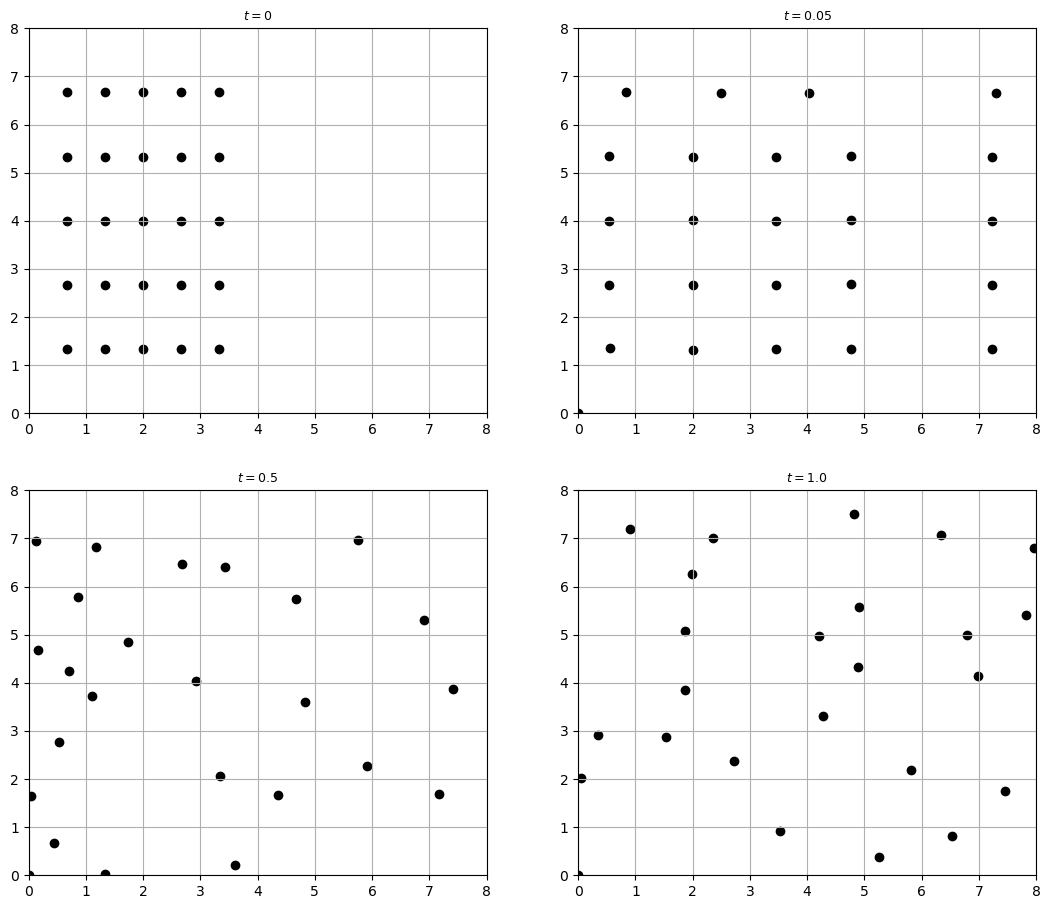

In [11]:
# Ячейка № 11

# визуализация мгновенных
# положений частиц в выбранные
# моменты времени

fig = plt.figure(figsize=(13, 11))
# визуализация положений частиц
# в момент времени t = 0
ax = plt.subplot(2, 2, 1)

ax.scatter(md[:, 0, 0], md[:, 1, 0], color="black", marker="o")
ax.axis([0, Lx, 0, Ly])
ax.set_title(r"$t = 0$", fontsize=9)
ax.grid(True)

# визуализация положений частиц
# в момент времени t = 0.05
ax = plt.subplot(2, 2, 2)
ax.scatter(md[:, 0, 500], md[:, 1, 500], color="black", marker="o")
ax.axis([0, Lx, 0, Ly])
ax.set_title(r"$t=0.05$", fontsize=9)
ax.grid(True)

# визуализация положений частиц
# в момент времени t = 0.5
ax = plt.subplot(2, 2, 3)
ax.scatter(md[:, 0, 5 * 10**3], md[:, 1, 5 * 10**3], color="black", marker="o")
ax.axis([0, Lx, 0, Ly])
ax.set_title(r"$t = 0.5$", fontsize=9)
ax.grid(True)

# визуализация положений частиц
# в момент времени t = 1.0
ax = plt.subplot(2, 2, 4)
ax.scatter(md[:, 0, 10**4], md[:, 1, 10**4], color="black", marker="o")
ax.axis([0, Lx, 0, Ly])
ax.set_title(r"$t = 1.0$", fontsize=9)
ax.grid(True)

plt.show()


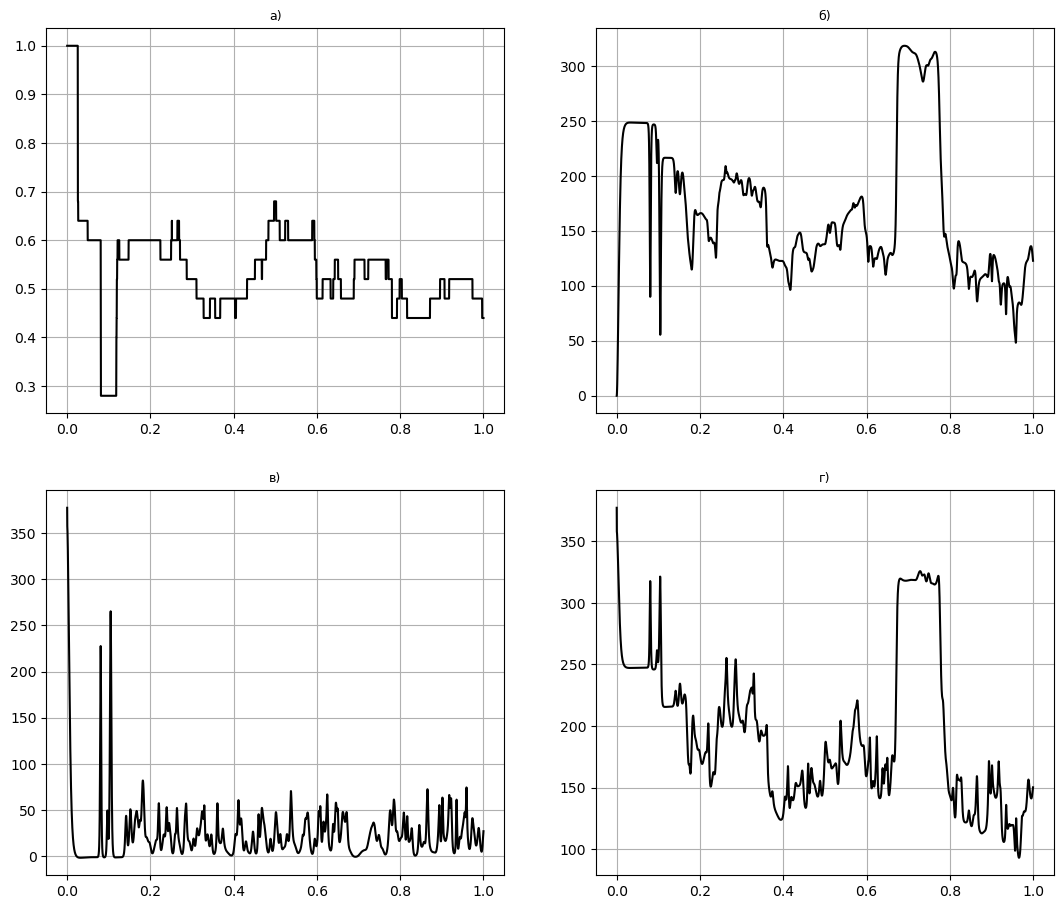

In [ ]:
# Ячейка № 12

# визуализация зависимостей:
# 1) числа частиц в левой половине ящика;
# 2) суммарной кинетической энергии частиц,
# отнесенной к числу частиц;
# 3) суммарной потенциальной энергии
# взаимодействия частиц,
# отнесенной к числу частиц;
# 4) полной суммарной энергии частиц,
# отнесенной к числу частиц,
# от времени

# задание числа массивов
# размерностью N x 7, размещенных
# в массиве md размерностью N x 7 X i
N_arr = Ni + 1

# инициализация массивов,
# используемого для
# вычисления мгновенных значений
# количества частиц, находящихся
# в левой половине ящика N_left[i],
# i = 0,1,...Т_arr
N_left = np.zeros(N_arr)
tmp = np.zeros(N)

# вычисление значений
# зависимости N_left[i]
# в левой половине ящика
for i in range(N_arr):
    tmp = md[:, 0, i]
    for j in range(N):
        if tmp[j] <= Lx / 2:
            N_left[i] = N_left[i] + 1

# инициализация массивов, используемых
# для вычисления мгновенных значений
# зависимостей суммарных
# кинетической (Ek[i]), потенциальной (Ep[i]),
# полной (Ek[i] + Ep[i]) энергий
#  частиц системы от времени
# (t[i] = i * dt)

tmp_Vx = np.zeros(N)
tmp_Vy = np.zeros(N)
Ek = np.zeros(N_arr)
Ep = np.zeros(N_arr)

# вычисление мгновенных значений
# зависимостей Ek[i],Ep[i]

for i in range(N_arr):
    Sum = 0
    tmp_Vx = md[:, 2, i]
    tmp_Vy = md[:, 3, 1]
    for j in range(N):
        Sum = Sum + 0.5 * (tmp_Vx[j] ** 2 + tmp_Vy[j] ** 2)
    Ek[i] = Sum
    Ep[i] = md[N - 1, 6, i]

i = np.arange(0, N_arr, 1, dtype=int)

# визуализация зависимостей
# N_left[i], Ek[i], Ep[i],
# Ek[i] + Ep[i]
fig = plt.figure(figsize=(13, 11))

# визуализация зависимости N_left[i]
ax = plt.subplot(2, 2, 1)
ax.plot(i * dt, N_left[i] / N, color="black")
ax.grid(True)
ax.set_title("а)", fontsize=9)

# визуализация зависимостей Ek[i]
ax = plt.subplot(2, 2, 2)
ax.plot(i * dt, Ek[i] / N, color="black")
ax.grid(True)
ax.set_title("б)", fontsize=9)

# визуализация зависимости Ep[i],
ax = plt.subplot(2, 2, 3)
ax.plot(i * dt, Ep[i] / N, color="black")
ax.grid(True)
ax.set_title("в)", fontsize=9)

# визуализация зависимости Ek[i] + Ep[i]
ax = plt.subplot(2, 2, 4)
ax.plot(i * dt, (Ek[i] + Ep[i]) / N, color="black")
ax.grid(True)
ax.set_title("г)", fontsize=9)

plt.show()


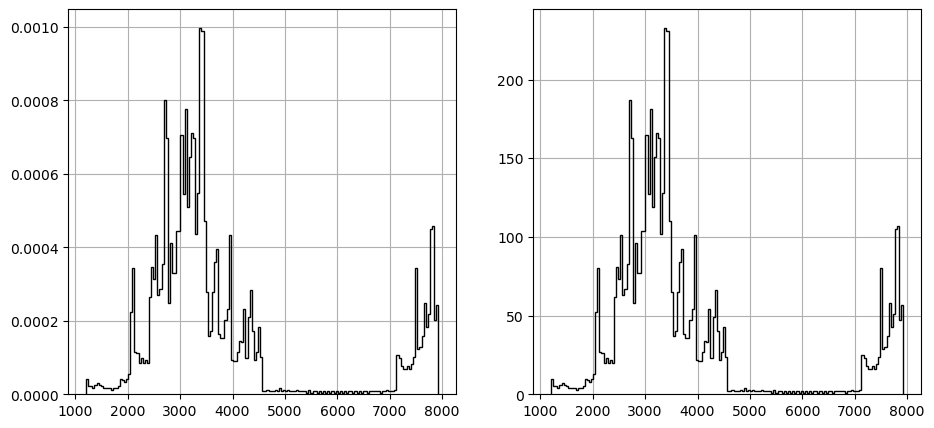

Оценка значения вероятности по первой гистограмме: 1.0
Оценка значения вероятности по второй гистограмме: 0.972337943676054


In [13]:
# Ячейка № 13

# визуализация гистограмм
# значений проекций
# частиц скоростей
# на соответствующие оси координат,
# нормированных на длину
# на длину интервалов гистограмм

tmp_Vx = np.zeros(N)

tmp_Vy = np.zeros(N)

tmp_V = np.zeros(N)

Vx_all = np.zeros(N)

Vy_all = np.zeros(N)

V2_all = np.zeros(N)

Vx_all[:] = md[:, 2, 0]

Vy_all[:] = md[:, 3, 0]

V2_all[:] = np.sqrt(md[:, 2, 0] ** 2 + md[:, 3, 0] ** 2)

for i in range(1, Ni + 1):
    tmp_Vx = md[:, 2, i]
    tmp_Vy = md[:, 3, i]
    tmp_V2 = md[:, 2, i] ** 2 + md[:, 3, i] ** 2
    Vx_all = np.hstack((Vx_all, tmp_Vx))
    Vy_all = np.hstack((Vy_all, tmp_Vy))
    V2_all = np.hstack((V2_all, tmp_V))

# задание момента времени,
# начиная с которого
# состояние системы
# считается равновесным
T_start = 0.4

# номер элемента массива md,
# соответствующий T_start
N_start = int(T_start / dt)

# вычисляем число элементов
# массива md, соответствующих
# равновесному состоянию
# моделируемой системы
Ng = Ni + 1 - N_start

Vx_part = np.zeros(Ng)

Vy_part = np.zeros(Ng)

V2_part = np.zeros(Ng)

# перемещение значения проекций
# скоростей частиц на оси координат,
# в моменты времени, соответствующие
# равновесному состоянию
# моделируемой системы,
# из массива md в массивы
# Vx_part, Vy_part, соответственно
j = 0
for i in range(N_start, Ni):
    Vx_part[j] = Vx_all[i]
    Vy_part[j] = Vy_all[i]
    V2_part[j] = V2_all[i]
    j = j + 1

#  задание интервалов гистограммы
xbins = np.arange(np.min(Ek[N_start : Ni + 1]), np.max(Ek[N_start : Ni + 1]), 40)

fig = plt.figure(figsize=(11, 5))

# визуализация гистограммы,
# нормированную на длину интервала,
# значений, размещенных
# в массиве Vx_part
plt.subplot(1, 2, 1)
E1_hist = plt.hist(
    Ek[N_start : Ni + 1], bins=xbins, histtype="step", color="black", density=True
)
plt.grid(True)

# визуализация гистограммы
# значений, размещенных
# в массиве Vy_part,
# нормированной на длину
# интервала гистограммы,
plt.subplot(1, 2, 2)
E2_hist = plt.hist(
    Ek[N_start : Ni + 1], bins=xbins, histtype="step", color="black", density=False
)
plt.grid(True)
plt.show()

print(
    "Оценка значения вероятности по первой гистограмме:",
    np.sum(E1_hist[0]) * (xbins[1] - xbins[0]),
)
print(
    "Оценка значения вероятности по второй гистограмме:",
    np.sum(E2_hist[0]) / len(Ek[N_start : Ni + 1]),
)

plt.show()